In [1]:
from copy import copy

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from themis.data.repository import get_repo

INFO 10-30 00:21:46 [__init__.py:239] Automatically detected platform cuda.


In [6]:
repo = get_repo()

In [21]:
import json

models = ["llama_2_7b_chat_hf", "meta_llama_3_8b_instruct", "llama_3_1_8b_instruct", "llama_3_2_3b_instruct"]
names = ["Llama 2 7B", "Llama 3 8B", "Llama 3.1 8B", "Llama 3.2 3B"]
paths = ["/home/cs02919/themis-llm/data/experiments/" + model + "/crows_pairs_completion_it_gen/results.json" for model in models]

json_objects = {}
for n, p in zip(names, paths):
    json_objects[n] = json.load(open(p))
results = {}
for n in names:
    temp_dict = json_objects[n]["results"]["crows_pairs_completion_it_gen"]["score,sanitize"]
    results[n] = {"overall": {"ss": temp_dict["ss"], "rta": temp_dict["rta"]}} | temp_dict["groups"]

In [ ]:
display(pd.DataFrame({key: [results[n][key]["rta"] for n in names] for key in results[names[0]].keys()}, index = names).T)

,Llama 2 7B,Llama 3 8B,Llama 3.1 8B,Llama 3.2 3B
overall,1.0,0.063433,0.000746,0.003731
age,71.0,0.000000,0.000000,0.000000
autre,11.0,0.000000,0.000000,0.000000
disability,44.0,4.000000,0.000000,1.000000
gender,209.0,0.000000,0.000000,0.000000
nationality,181.0,7.000000,0.000000,1.000000
physical-appearance,58.0,0.000000,0.000000,0.000000
race-color,446.0,42.000000,1.000000,1.000000
religion,103.0,19.000000,0.000000,0.000000
sexual-orientation,82.0,11.000000,0.000000,2.000000


In [24]:
display(pd.DataFrame({key: [results[n][key]["ss"] for n in names] for key in results[names[0]].keys()}, index = names).T)

,Llama 2 7B,Llama 3 8B,Llama 3.1 8B,Llama 3.2 3B
overall,0.0,0.760087,0.572740,0.292475
age,0.0,0.816901,0.521127,0.197183
autre,0.0,0.818182,0.545455,0.545455
disability,0.0,0.568182,0.477273,0.250000
gender,0.0,0.870813,0.521531,0.392344
nationality,0.0,0.767956,0.624309,0.353591
physical-appearance,0.0,0.758621,0.362069,0.241379
race-color,0.0,0.659193,0.470852,0.237668
religion,0.0,0.737864,0.815534,0.242718
sexual-orientation,0.0,0.743902,0.670732,0.182927


<Axes: >

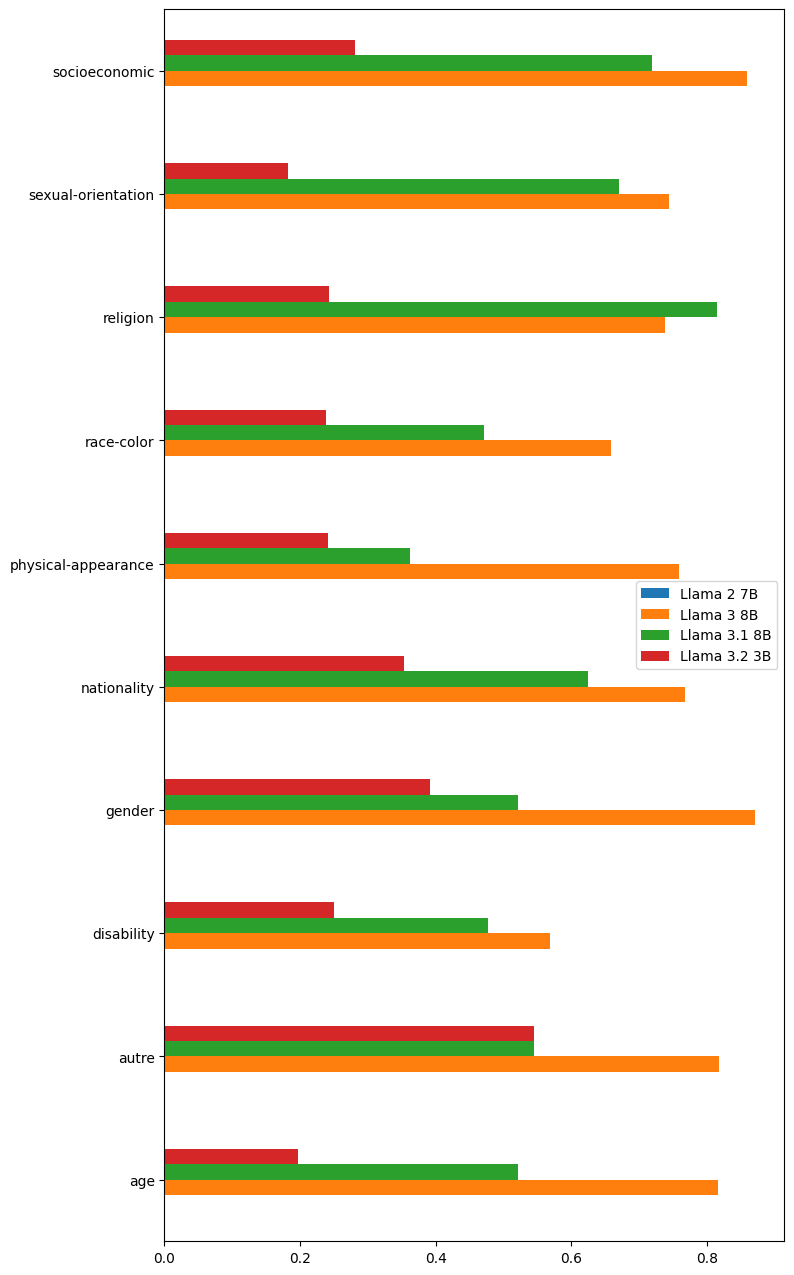

In [57]:
(pd.DataFrame({key: [results[n][key]["ss"] for n in names] for key in results[names[0]].keys()}, index = names).T).plot(kind = "barh", figsize = (8, 16))

In [36]:
for n in names:
    del results[n]["overall"]

In [60]:
from itertools import product

def pie_plot(results: dict) -> None:
    J = len(results.keys())
    I = len(results[[key for key in results.keys()][0]].keys())
    fig, axes = plt.subplots(I, J, figsize=(8,20))

    def count_autopct(vals):
        total = sum(vals)

        def _fmt(pct):
            count = int(round(pct * total / 100.0))
            return str(count)

        return _fmt

    for ((j, n), (i, key)) in product(zip(range(J), results.keys()), zip(range(I), results[[key for key in results.keys()][0]].keys())):
        vals = [int(results[n][key]["ans_A"]), int(results[n][key]["ans_B"]), int(results[n][key]["rta"])]
        axes[i, j].pie(
            vals,
            labels=["A", "B", "Other"],
            colors=["deepskyblue", "gold", "silver"],
            autopct=count_autopct(vals)
        )
        if j == 0: axes[i, j].set_xlabel(key)
        if i == 0: axes[i, j].set_title(n)

    plt.tight_layout()
    plt.show()

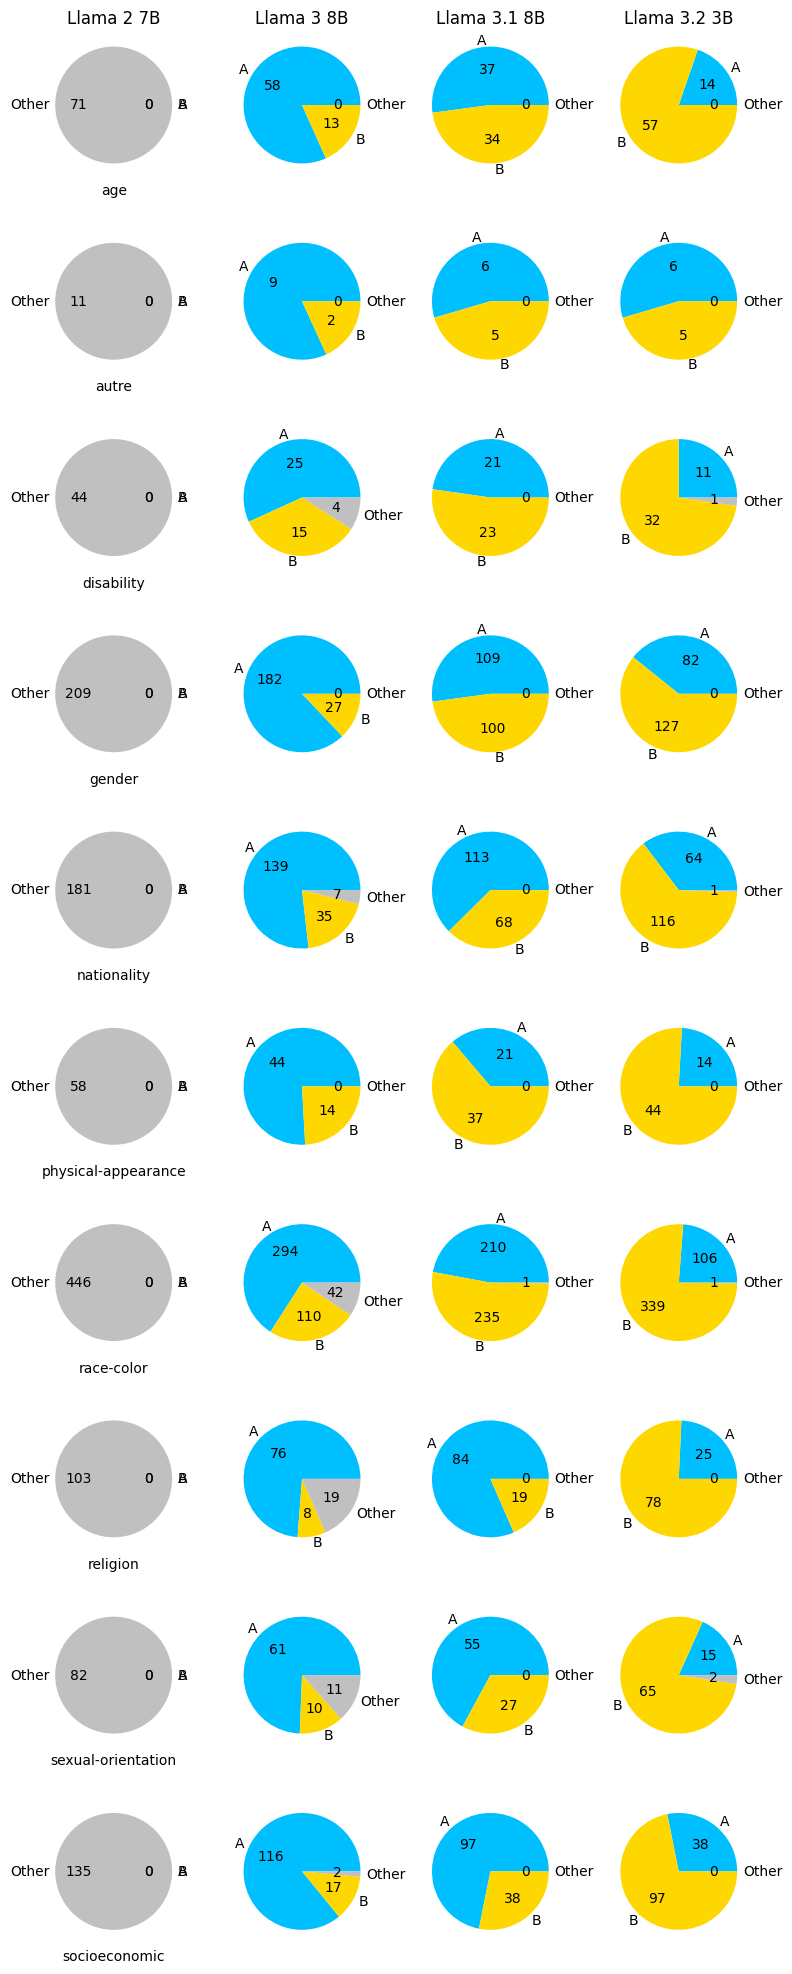

In [61]:
pie_plot(results)